In [4]:
import pandas as pd

In [5]:
pd.set_option('display.max.columns',9)
pd.set_option('display.max.rows',1000)

In [13]:
#Full dataset
df = pd.read_csv("retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24/11/2023,CUST001,Male,34,Beauty,3,50,150
1,2,27/02/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13/01/2023,CUST003,Male,50,Electronics,1,30,30
3,4,21/05/2023,CUST004,Male,37,Clothing,1,500,500
4,5,06/05/2023,CUST005,Male,30,Beauty,2,50,100
5,6,25/04/2023,CUST006,Female,45,Beauty,1,30,30
6,7,13/03/2023,CUST007,Male,46,Clothing,2,25,50
7,8,22/02/2023,CUST008,Male,30,Electronics,4,25,100
8,9,13/12/2023,CUST009,Male,63,Electronics,2,300,600
9,10,07/10/2023,CUST010,Female,52,Clothing,4,50,200


In [9]:
#Inspection
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24/11/2023,CUST001,Male,34,Beauty,3,50,150
1,2,27/02/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13/01/2023,CUST003,Male,50,Electronics,1,30,30
3,4,21/05/2023,CUST004,Male,37,Clothing,1,500,500
4,5,06/05/2023,CUST005,Male,30,Beauty,2,50,100


In [8]:
#Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 54.8+ KB


In [9]:
#Stats
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [10]:
#Missing Values
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [11]:
#Duplicates
df.duplicated().sum()

np.int64(0)

In [16]:
#Change date type from object to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 58.7+ KB


In [18]:
#Total Sales 
df["Total Amount"].sum()

np.int64(456000)

In [19]:
#Sales by Gender 
df.groupby("Gender")["Total Amount"].sum()

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

In [20]:
#Sales by Product
df.groupby("Product Category")["Total Amount"].sum()

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

In [21]:
#Sales by Product Descending 
df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

In [22]:
#Average Purchase by Age 
df.groupby("Age")["Total Amount"].mean()

Age
18    534.047619
19    708.095238
20    411.666667
21    629.250000
22    507.407407
23    342.500000
24    361.000000
25    495.000000
26    635.454545
27    408.043478
28    412.857143
29    410.625000
30    445.000000
31    464.545455
32    292.105263
33    624.000000
34    599.464286
35    513.181818
36    607.000000
37    728.125000
38    584.210526
39    255.277778
40    392.291667
41    269.047619
42    326.923077
43    579.677419
44    504.000000
45    372.058824
46    523.600000
47    480.961538
48    402.222222
49    268.947368
50    428.043478
51    535.500000
52    320.000000
53    559.411765
54    375.178571
55    465.714286
56    496.842105
57    309.666667
58    528.214286
59    557.058824
60    526.818182
61    373.888889
62    300.740741
63    544.117647
64    294.354839
Name: Total Amount, dtype: float64

In [23]:
#Date type converted from object to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [24]:
#Date type converted from object to datetime
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 58.7+ KB


In [25]:
#Excracted Month
df["Month"] = df["Date"].dt.month

In [26]:
#Sales per Month
df.groupby("Month")["Total Amount"].sum()

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

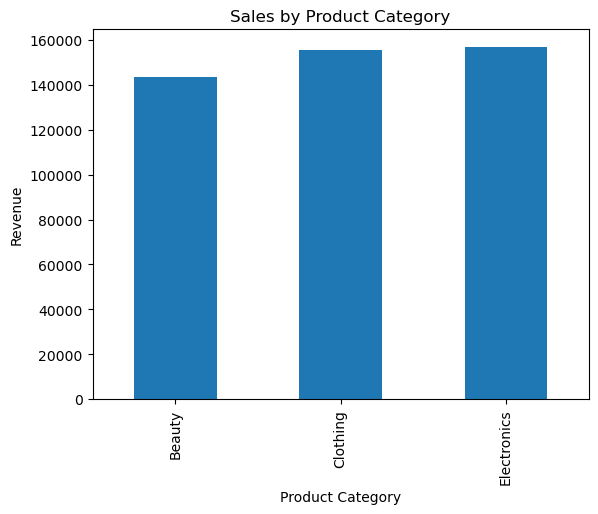

In [27]:
#Sales by Category Visualization
import matplotlib.pyplot as plt

sales = df.groupby("Product Category")["Total Amount"].sum()

sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.ylabel("Revenue")
plt.show()

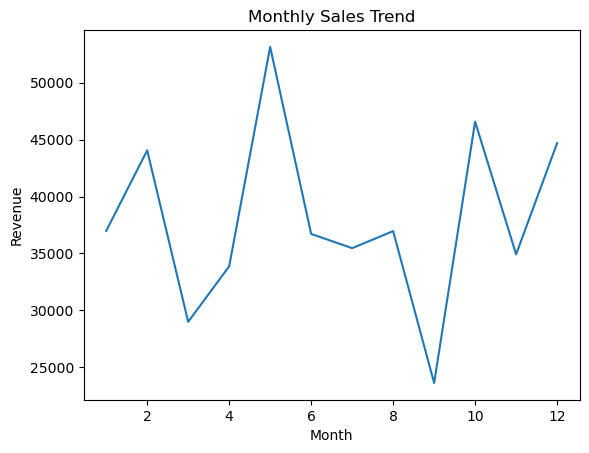

In [28]:
#Monthly Sales Visualization 
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()